# Compare notebook and production workflow outputs

Compare with WP 1.2 notebook output.

In [1]:
#!pip install --upgrade odc-stats datacube

In [2]:
import datacube
import xarray as xr
import numpy as np

from matplotlib import pyplot as plt

In [3]:
!ls /home/jovyan/dev/deafrica_water_quality/WP1.2/

 Build_annual_dataset-1.0.ipynb   _Build_annual_dataset-1.0.ipynb
 Lake_Baringo.nc		  _WQ_functions.py
 Lake_Baringo_raw.nc		  distributions.csv
'WQ package 1.2.ipynb'		  msi_OWT_vectors.csv
'WQ package 1.2_Fang.ipynb'	  oli_OWT_vectors.csv
 WQ_functions.py		  tm_OWT_vectors.csv
 Water_quality_FAI.ipynb


## Data saved from notebook workflow

In [4]:
# use AOI, 100 m resolution, bilinear for all products except water (nearest)
ds_file = "/home/jovyan/dev/deafrica_water_quality/WP1.2/Lake_Baringo.nc"
saved = xr.open_dataset(ds_file)
saved = saved.sel(time="2023").squeeze()

In [5]:
list(saved.data_vars)

['wofs_ann_freq',
 'wofs_ann_clearcount',
 'wofs_ann_wetcount',
 'wofs_ann_freq_sigma',
 'wofs_ann_confidence',
 'wofs_pw_threshold',
 'wofs_ann_pwater',
 'wofs_ann_water',
 'watermask',
 'wofs_5yr_freq',
 'wofs_5yr_clearcount',
 'wofs_5yr_wetcount',
 'water_5yr',
 'agm_count',
 'oli_agm',
 'tm_agm',
 'msi_agm',
 'msi_agm_fai',
 'oli_agm_fai',
 'tm_agm_fai',
 'agm_fai',
 'fai_cover',
 'msi_agm_ndvi',
 'oli_agm_ndvi',
 'tm_agm_ndvi',
 'agm_ndvi',
 'ndvi_cover',
 'clearwater',
 'agm_hue',
 'oli_agm_hue',
 'msi_agm_hue',
 'tm_agm_hue',
 'agm_owt',
 'tss',
 'chla',
 'tss_scale',
 'tss_offset',
 'tss_era_factor',
 'chla_scale',
 'chla_offset',
 'chla_era_factor',
 'tss_h',
 'chla_h',
 'fai_tm_h',
 'fai_oli_h',
 'fai_msi_h',
 'ndvi_tm_h',
 'ndvi_oli_h',
 'ndvi_msi_h',
 'hue_tm_h',
 'hue_oli_h',
 'hue_msi_h']

In [6]:
saved['tss_final']= saved['tss_h'].median(dim=('tss_measure'))
saved['chla_final'] = saved['chla_h'].median(dim=('chla_measure'))

## Data from WP1.3

Lake Baringo AOI, 100 m res

In [7]:
import glob
files = glob.glob("../WP1.3/test100/wq_annual/1-0-0/x217/y077/2023--P1Y/wq_annual_x217y077_2023--P1Y_*.tif")

In [8]:
import rioxarray as rxr

datasets = [rxr.open_rasterio(f).squeeze().to_dataset(name='_'.join(f.split("/")[-1].split('.')[0].split('_')[4:])) for f in files]
ds = xr.merge(datasets)

/tmp/ipykernel_3409/2089178611.py:4: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(datasets)
/tmp/ipykernel_3409/2089178611.py:4: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(datasets)


In [9]:
list(ds.data_vars)

['tm_agm_fai',
 'tirs_st_ann_med',
 'agm_hue',
 'chla',
 'clear_water',
 'oli_agm_fai',
 'oli_agm_owt',
 'agm_owt',
 'msi_agm_owt',
 'tm_agm_owt',
 'msi_agm_fai',
 'tm_agm_ndvi',
 'oli_agm_ndvi',
 'tm_agm_hue',
 'tsi',
 'agm_ndvi',
 'water_mask',
 'msi_agm_hue',
 'tsm',
 'oli_agm_hue',
 'agm_fai',
 'tirs_st_ann_min',
 'tirs_st_ann_max',
 'msi_agm_ndvi']

In [10]:
# Compare parameters

def compare(param, param_saved=None, plot=False):
    if param_saved is None:
        param_saved = param
        
    indexed = ds[param]
    saved_param = saved[param_saved]

    # value difference
    diff = abs(indexed -saved_param)
    print(f"{param} min, max difference", diff.min().values, diff.max().values)

    # valid value coverage difference
    ds_valid = (~ds[param].isnull()).sum().values
    saved_valid = (~saved[param_saved].isnull()).sum().values
    if ds_valid !=saved_valid:
        print("different valid area:", ds_valid, saved_valid)

    # plot
    if (diff.max().values > 0) or plot:
        if "hue" in param:
            plt.figure();
            indexed.plot.imshow(cmap='hsv', vmin=0, vmax=360)
            plt.figure();
            saved_param.plot.imshow(cmap='hsv', vmin=0, vmax=360);
        else:
            plt.figure();
            indexed.plot.imshow(robust=True)
            plt.figure();
            saved_param.plot.imshow(robust=True);
            plt.figure();
            (indexed-saved_param).plot.imshow(robust=True);
    return diff, indexed, saved_param

In [11]:
# clear water mask matches. 
# Water mask is bigger than clear water mask in production. Intended?

diff, indexed, saved_param  = compare('water_mask', "water_5yr")
diff, indexed, saved_param  = compare("clear_water", "clearwater")

water_mask min, max difference 0.0 0.0
different valid area: 21930 21313
clear_water min, max difference 0.0 0.0


In [12]:
# OWT good 
diff, indexed, saved_param  = compare('agm_owt')

agm_owt min, max difference 0.0 0.0


agm_ndvi min, max difference 9.164143055517826e-11 1.6686804688026413e-08
different valid area: 661 88


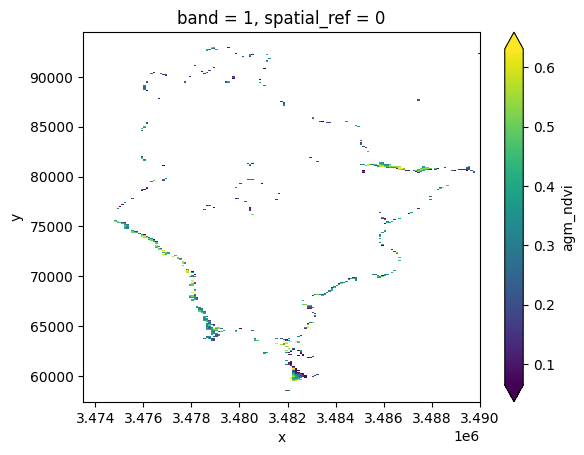

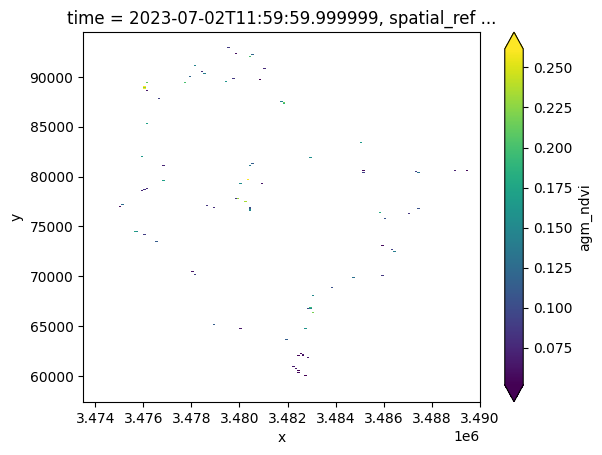

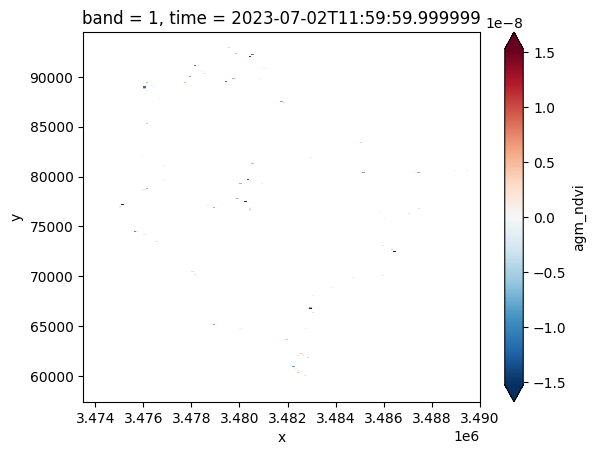

In [13]:
# NDVI have different coverage, either from water mask or slight difference in positive values
diff, indexed, saved_param  = compare('agm_ndvi')

agm_hue min, max difference 14.373711913060056 50.511677246348725
different valid area: 6787 21313


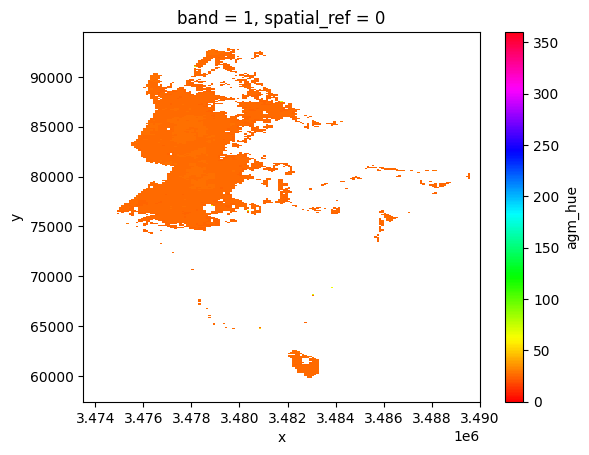

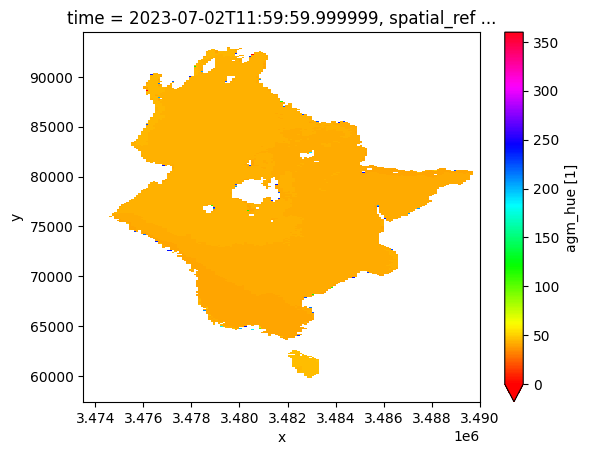

In [14]:
# hue have different coverage
diff, indexed, saved_param = compare("agm_hue")

msi_agm_hue min, max difference 0.0 0.0
different valid area: 21253 21313


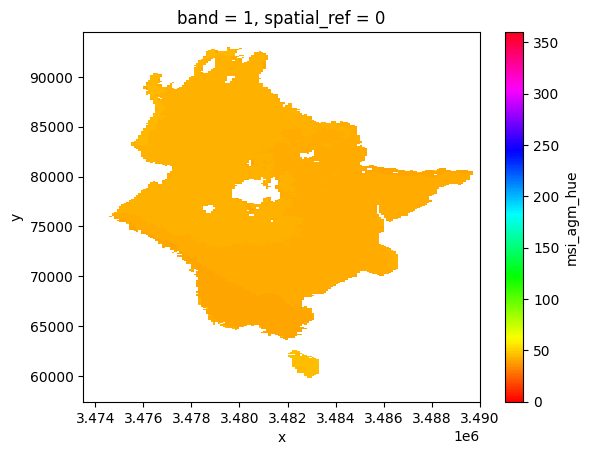

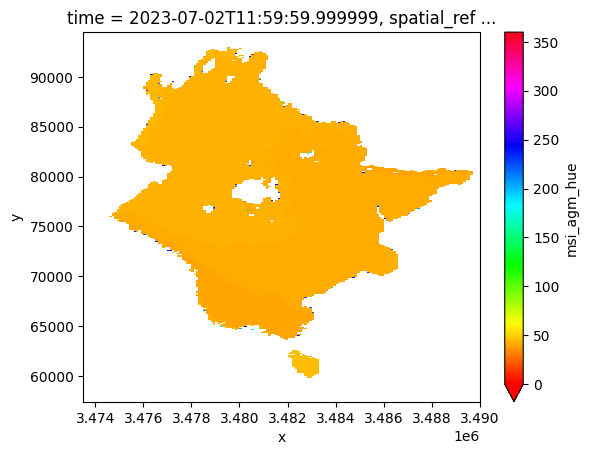

In [15]:
# msi looks close, seems there's a problem with merging into agm_hue
diff, indexed, saved_param  = compare('msi_agm_hue', plot=True) 

agm_fai min, max difference nan nan
different valid area: 527 0


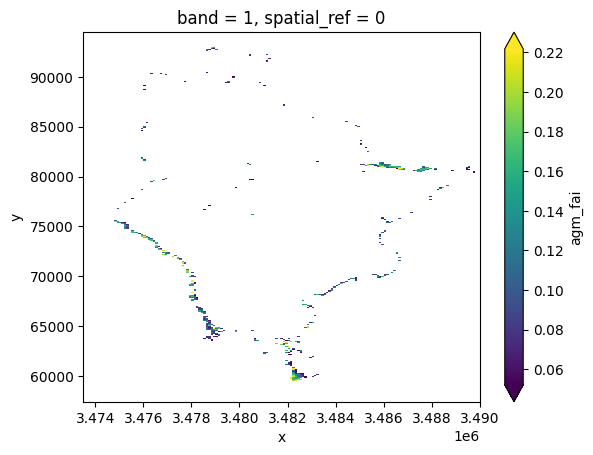

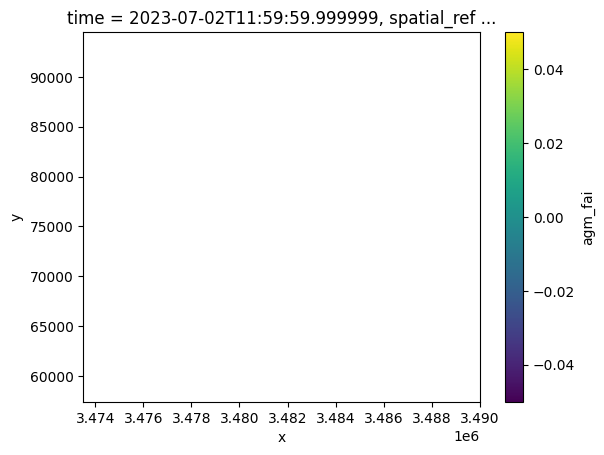

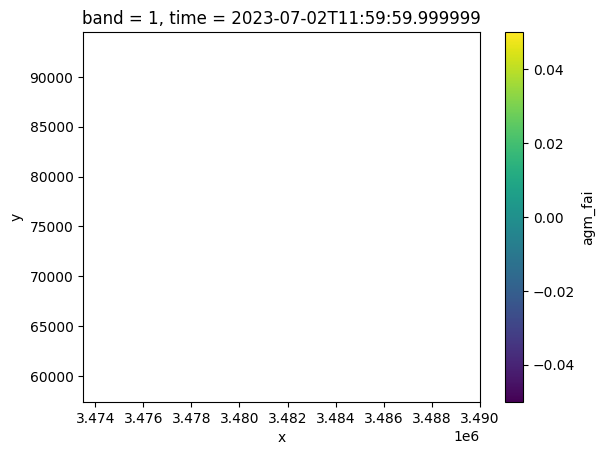

In [16]:
# different mask/coverage, no fai value saved in WP1.2 notebook?
diff, indexed, saved_param  = compare('agm_fai', plot=True)

chla min, max difference 0.0 1.929962866142887e-05
different valid area: 21930 21313


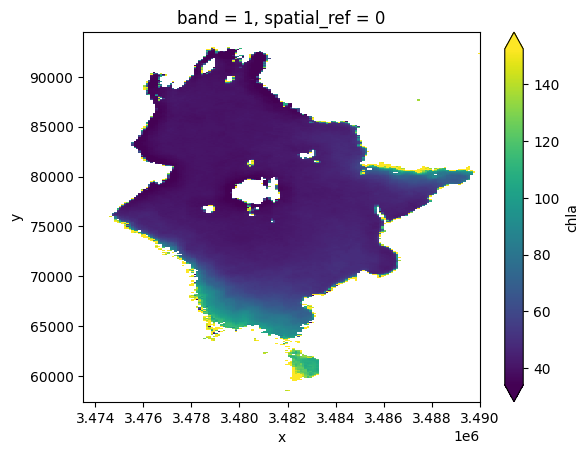

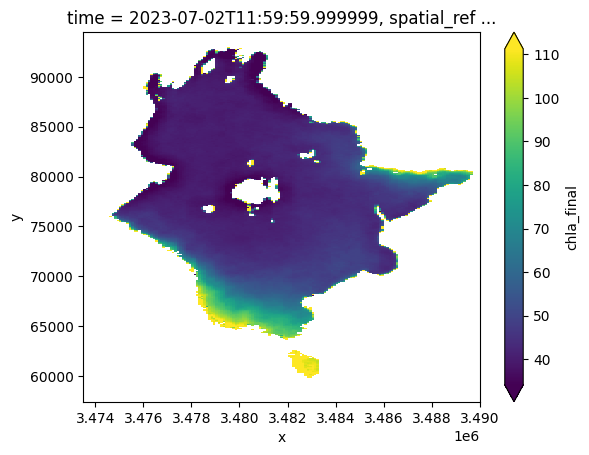

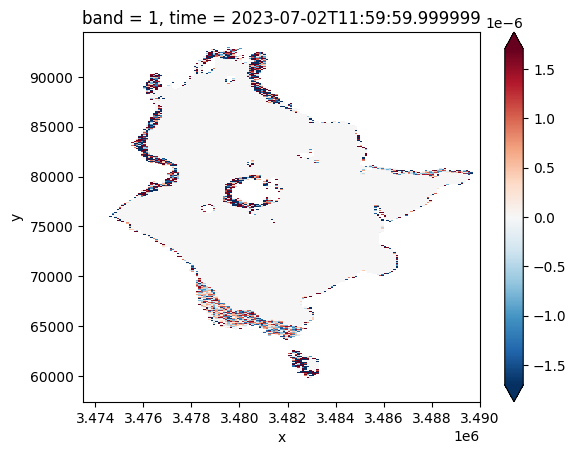

In [17]:
# differerent mask, value seems very close
diff, indexed, saved_param = compare("chla", "chla_final")

tsm min, max difference 0.0 5.1152438402368716e-05
different valid area: 21930 21313


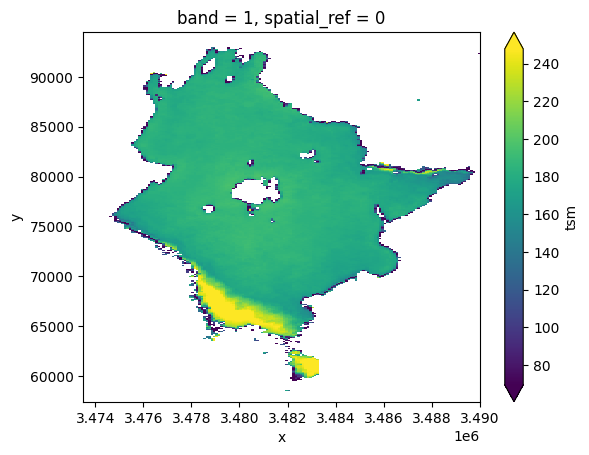

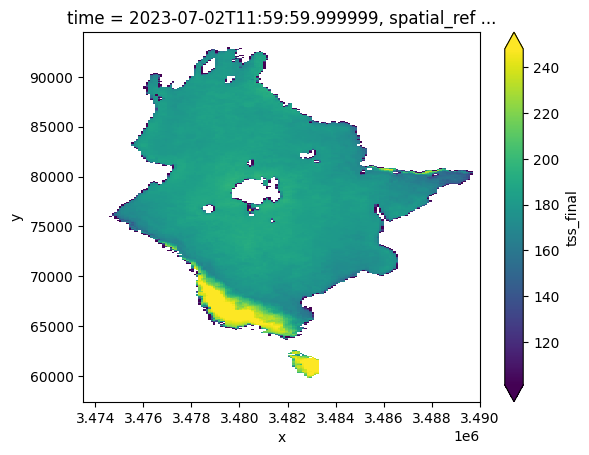

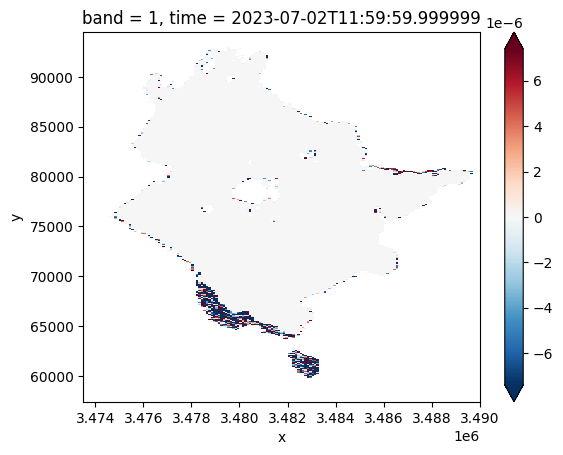

In [18]:
# differerent mask, value seems very close
diff, indexed, saved_param = compare("tsm", "tss_final")